# Genetic Algorithm
Note: <br>
For this algorithm to run the clients, employees and their nearest_segments have to be calculated in advance.

Genetic representation: <br>
List of clients in order of being calculated.

Mutation: <br>
Swap mutation to change the path randomly. Each mutation will use one parent to make sure no duplicate clients get added.

Tournament selection: <br>
Used to get a fair spread of good and bad states.

Elitism survivor selection: <br>
To make sure we do not go back in progress.

In [44]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import osmnx as ox
import numpy as np
from shapely import wkt

In [45]:
# Initialize all necessary parts of the genetic algorithm
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

POPULATION_SIZE = 100
EPOCHS = 500

MUTATION_RATE = 1.00
MUTATION_STRIDE = 2

TOURNAMENT_SIZE = 5
ELITE_SIZE = max(1, int(0.10 * POPULATION_SIZE))

MAX_EMPLOYEE_WORK_TIME_MIN = 8 * 60

print("GA initialized:")
print(f"  seed={RANDOM_SEED}, population={POPULATION_SIZE}, epochs={EPOCHS}")
print(f"  mutation_rate={MUTATION_RATE}, mutation_stride={MUTATION_STRIDE}")
print(f"  tournament={TOURNAMENT_SIZE}, elite_size={ELITE_SIZE}")

GA initialized:
  seed=42, population=100, epochs=500
  mutation_rate=1.0, mutation_stride=2
  tournament=5, elite_size=10


In [46]:
# ============= Initial Population =============
NUM_CLIENTS = 100
client_indices = list(range(NUM_CLIENTS))
initial_population = [np.random.permutation(client_indices).tolist() for _ in range(POPULATION_SIZE)]

print(f"Initialized population with {len(initial_population)} individuals.")
print(f"Each individual contains {len(initial_population[0])} client indices.")
print("First individual:")
print(initial_population[0])

Initialized population with 100 individuals.
Each individual contains 100 client indices.
First individual:
[83, 53, 70, 45, 44, 39, 22, 80, 10, 0, 18, 30, 73, 33, 90, 4, 76, 77, 12, 31, 55, 88, 26, 42, 69, 15, 40, 96, 9, 72, 11, 47, 85, 28, 93, 5, 66, 65, 35, 16, 49, 34, 7, 95, 27, 19, 81, 25, 62, 13, 24, 3, 17, 38, 8, 78, 6, 64, 36, 89, 56, 99, 54, 43, 50, 67, 46, 68, 61, 97, 79, 41, 58, 48, 98, 57, 75, 32, 94, 59, 63, 84, 37, 29, 1, 52, 21, 2, 23, 87, 91, 74, 86, 82, 20, 60, 71, 14, 92, 51]


In [47]:
# ============= Mutation Function =============
def swap_mutation(parent):
    """
    Swap mutation: takes a single parent (list of client indices),
    creates a mutant by swapping MUTATION_STRIDE random position pairs.
    
    Args:
        parent: list of client indices representing a route order
        
    Returns:
        mutant: mutated copy of parent with swapped positions
    """
    mutant = parent.copy()
    
    # Perform MUTATION_STRIDE swaps
    for _ in range(MUTATION_STRIDE):
        # Select two random distinct indices
        i, j = np.random.choice(len(mutant), size=2, replace=False)
        # Swap them
        mutant[i], mutant[j] = mutant[j], mutant[i]
    
    return mutant

In [48]:
# ============= Tournament Selection =============
def tournament_selection(population, fitness_scores):
    """
    Tournament selection: randomly sample TOURNAMENT_SIZE individuals
    and return the best one (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        winner: selected individual from the tournament
        winner_fitness: fitness score of the selected individual
    """
    # Sample unique indices for the tournament
    tournament_size = min(TOURNAMENT_SIZE, len(population))
    candidate_indices = np.random.choice(len(population), size=tournament_size, replace=False)
    
    # Find index of the best candidate in the sampled set (lower fitness is better)
    best_local_idx = np.argmin([fitness_scores[i] for i in candidate_indices])
    winner_index = candidate_indices[best_local_idx]
    
    winner = population[winner_index]
    winner_fitness = fitness_scores[winner_index]
    
    return winner, winner_fitness

In [49]:
# ============= Elitism Selection =============
def elitism_selection(population, fitness_scores):
    """
    Elitism selection: preserve the top ELITE_SIZE individuals from the population
    based on their fitness scores (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        elite_individuals: list of the ELITE_SIZE best individuals
        elite_fitness: list of fitness scores for the elite individuals
    """
    # Get indices sorted by fitness (ascending - lower is better)
    sorted_indices = np.argsort(fitness_scores)[:ELITE_SIZE]
    
    # Extract elite individuals and their fitness scores
    elite_individuals = [population[i] for i in sorted_indices]
    elite_fitness = [fitness_scores[i] for i in sorted_indices]
    
    return elite_individuals, elite_fitness

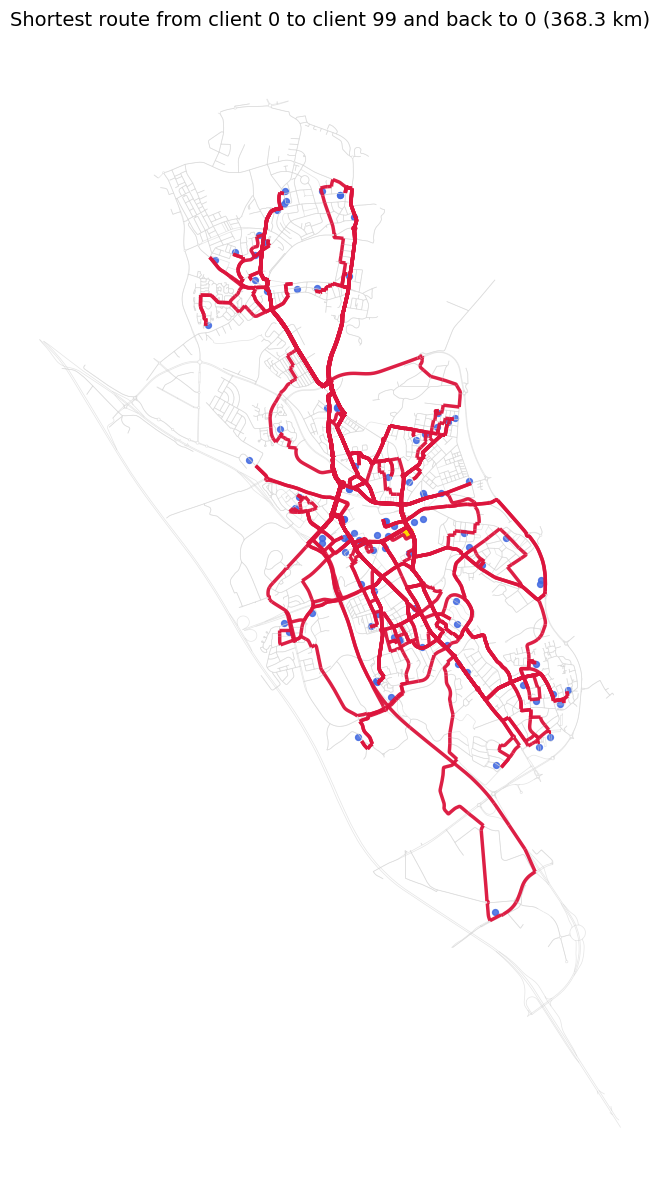

In [50]:
# Go from client 1 through each other client back to 1
import networkx as nx
from itertools import pairwise
from shapely.geometry import LineString

# Build a road graph from the edge table that already has corrected geometry direction.
road_graph = nx.MultiDiGraph()
road_graph.graph["crs"] = "EPSG:4326"

for _, edge_row in edges_gdf.iterrows():
    geometry = edge_row["geometry"]
    if geometry is None or geometry.is_empty:
        continue

    line_parts = list(geometry.geoms) if geometry.geom_type == "MultiLineString" else [geometry]
    edge_attributes = edge_row.drop(labels=["geometry", "key"]).to_dict()

    for line in line_parts:
        coordinates = list(line.coords)
        if len(coordinates) < 2:
            continue

        start_x, start_y = coordinates[0]
        end_x, end_y = coordinates[-1]
        road_graph.add_node(edge_row["u"], x=start_x, y=start_y)
        road_graph.add_node(edge_row["v"], x=end_x, y=end_y)
        road_graph.add_edge(edge_row["u"], edge_row["v"], key=edge_row["key"], geometry=line, **edge_attributes)

# Route through client 0 -> 1 -> ... -> 99 -> 0.
num_route_clients = min(100, len(clients_gdf))
route_client_indices = list(range(num_route_clients)) + [0]
route_client_points = clients_gdf.loc[route_client_indices, "geometry"]
route_client_nodes = ox.nearest_nodes(
    road_graph,
    route_client_points.x.to_list(),
    route_client_points.y.to_list(),
)

route_geometries = []
route_total_length_m = 0.0

for start_node, end_node in pairwise(route_client_nodes):
    path_nodes = nx.shortest_path(road_graph, start_node, end_node, weight="length")
    route_total_length_m += nx.path_weight(road_graph, path_nodes, weight="length")

    for node_u, node_v in pairwise(path_nodes):
        edge_bundle = road_graph.get_edge_data(node_u, node_v)
        if not edge_bundle:
            route_geometries.append(
                LineString(
                    [
                        (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                        (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                    ]
                )
            )
            continue

        best_key = min(
            edge_bundle,
            key=lambda candidate_key: edge_bundle[candidate_key].get("length", float("inf")),
        )
        selected_edge = edge_bundle[best_key]
        geometry = selected_edge.get("geometry")
        if geometry is None:
            geometry = LineString(
                [
                    (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                    (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                ]
            )
        route_geometries.append(geometry)

route_gdf = gpd.GeoDataFrame(geometry=route_geometries, crs="EPSG:4326").to_crs(epsg=3857)
edges_plot = edges_gdf.to_crs(epsg=3857)
clients_plot = clients_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.6)
route_gdf.plot(ax=ax, color="crimson", linewidth=2.5, alpha=0.95)
clients_plot.plot(ax=ax, color="royalblue", markersize=18, alpha=0.85)
clients_plot.iloc[[0]].plot(ax=ax, color="gold", markersize=50, alpha=1.0)

ax.set_title(
    f"Shortest route from client 0 to client 99 and back to 0 ({route_total_length_m / 1000:.1f} km)",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [51]:
clients_df = pd.read_csv("../output/clients.csv")
employees_df = pd.read_csv("../output/employees.csv")
clients_nearest_segments = pd.read_csv("../output/client_nearest_segments.csv")
employees_nearest_segments = pd.read_csv("../output/employee_nearest_segments.csv")
heerlen_edge_table = pd.read_csv("../output/heerlen_edge_table.csv")

In [52]:
import networkx as nx

client_order = list(range(100))


def _build_travel_graph_from_edge_table(edge_table):
    graph = nx.DiGraph()
    for row in edge_table.itertuples(index=False):
        try:
            node_u = int(getattr(row, "u"))
            node_v = int(getattr(row, "v"))
            travel_time = float(getattr(row, "travel_time"))
        except Exception:
            continue

        if np.isnan(travel_time) or travel_time < 0:
            continue

        if graph.has_edge(node_u, node_v):
            graph[node_u][node_v]["weight"] = min(graph[node_u][node_v]["weight"], travel_time)
        else:
            graph.add_edge(node_u, node_v, weight=travel_time)

        if graph.has_edge(node_v, node_u):
            graph[node_v][node_u]["weight"] = min(graph[node_v][node_u]["weight"], travel_time)
        else:
            graph.add_edge(node_v, node_u, weight=travel_time)

    return graph


def _nearest_segment_for_name(frame, name_column, name_value):
    subset = frame[frame[name_column].astype(str) == str(name_value)]
    if subset.empty:
        raise ValueError(f"No nearest segment found for {name_column}={name_value}")
    return subset.sort_values("distance_m", ascending=True).iloc[0]


def get_employee_client_step_details(employee_id, client_id):
    """Return first-step travel/care details and the followed graph node path."""
    if int(client_id) < 0 or int(client_id) >= len(clients_df):
        raise IndexError("client_id is out of range for clients_df")

    employee_name = f"employee {int(employee_id)}"
    client_row = clients_df.iloc[int(client_id)]
    client_name = str(client_row["name"])

    employee_segment = _nearest_segment_for_name(
        employees_nearest_segments, "employee_name", employee_name
    )
    client_segment = _nearest_segment_for_name(
        clients_nearest_segments, "client_name", client_name
    )

    travel_graph = _build_travel_graph_from_edge_table(heerlen_edge_table)

    employee_nodes = [int(employee_segment["u"]), int(employee_segment["v"])]
    client_nodes = [int(client_segment["u"]), int(client_segment["v"])]

    best_minutes = float("inf")
    best_path = None

    for start_node in employee_nodes:
        for end_node in client_nodes:
            if start_node == end_node:
                if 0.0 < best_minutes:
                    best_minutes = 0.0
                    best_path = [start_node]
                continue
            try:
                candidate_path = nx.shortest_path(
                    travel_graph,
                    source=start_node,
                    target=end_node,
                    weight="weight",
                )
                candidate_minutes = nx.path_weight(travel_graph, candidate_path, weight="weight")
                if float(candidate_minutes) < best_minutes:
                    best_minutes = float(candidate_minutes)
                    best_path = candidate_path
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                continue

    if best_path is None:
        raise ValueError(
            f"No path found from {employee_name} segment to {client_name} segment using heerlen_edge_table."
        )

    care_hours = float(client_row.get("care_hours", 0.0))
    if np.isnan(care_hours) or care_hours < 0:
        care_hours = 0.0

    care_minutes = care_hours * 60.0
    total_minutes = best_minutes + care_minutes

    return {
        "employee_name": employee_name,
        "client_name": client_name,
        "travel_minutes": best_minutes,
        "care_minutes": care_minutes,
        "total_minutes": total_minutes,
        "path_nodes": best_path,
    }


def get_employee_client_step_minutes(employee_id, client_id):
    """Return total time in minutes (travel + care) for one employee->client first step."""
    details = get_employee_client_step_details(employee_id, client_id)
    return details["total_minutes"]


# Example call (employee 1 to client index 0).
get_employee_client_step_minutes(1, 0)

300.3209559151766

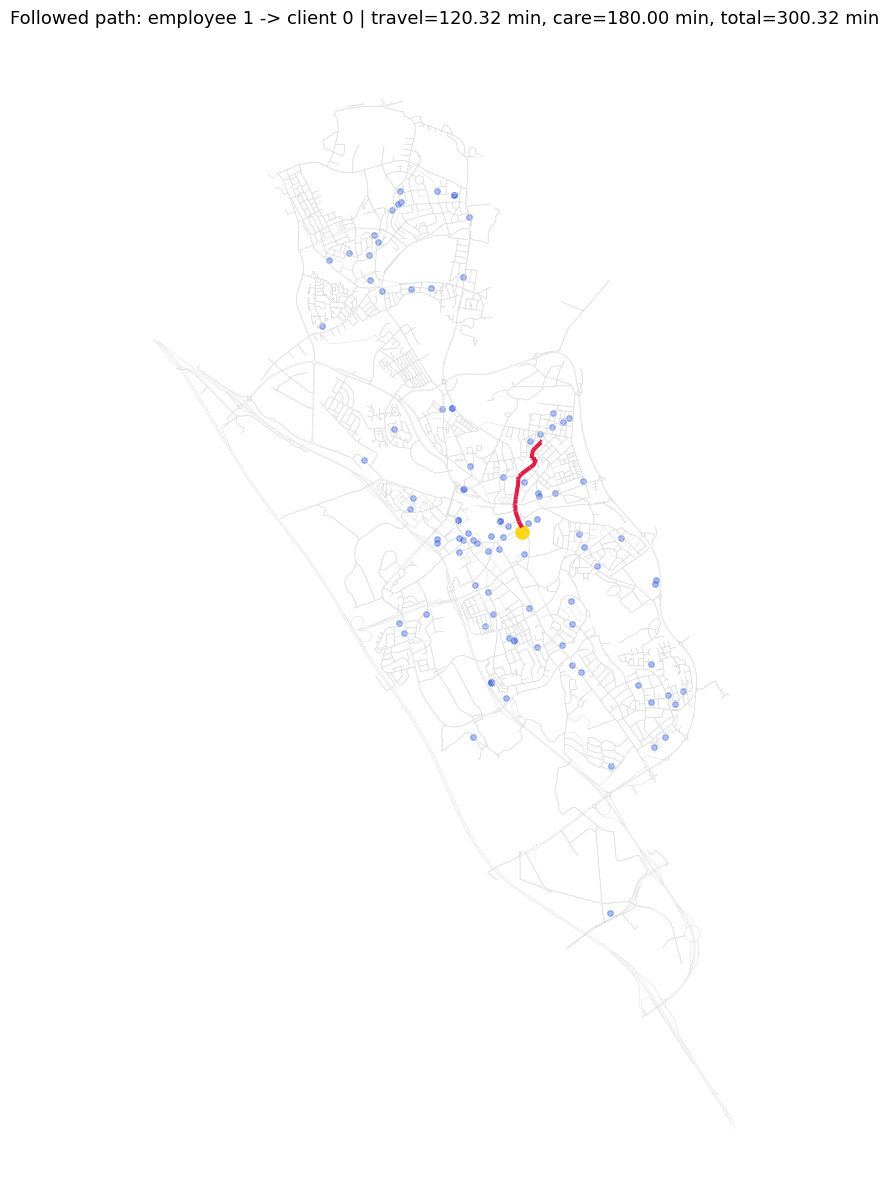

Followed path (node ids):
[42044822, 42044627, 4995414674, 42043743, 42043394, 42042819, 42042707, 42041823, 3126377818, 42040981, 1937150386, 1724265735, 42038089, 42037530, 11070185574, 694343749, 694343752, 11070185578, 1928612561, 3501091499, 42035244, 8832515619, 42033706, 42033003]


In [53]:
from itertools import pairwise
from shapely.geometry import LineString

# Plot the followed path for employee 1 to client index 0.
employee_id = 1
client_id = 0
step_details = get_employee_client_step_details(employee_id, client_id)
path_nodes = step_details["path_nodes"]

path_geometries = []
for node_u, node_v in pairwise(path_nodes):
    edge_candidates = edges_gdf[(edges_gdf["u"] == node_u) & (edges_gdf["v"] == node_v)]
    if edge_candidates.empty:
        edge_candidates = edges_gdf[(edges_gdf["u"] == node_v) & (edges_gdf["v"] == node_u)]

    if edge_candidates.empty:
        continue

    if "length" in edge_candidates.columns:
        selected_edge = edge_candidates.sort_values("length", ascending=True).iloc[0]
    else:
        selected_edge = edge_candidates.iloc[0]

    geometry = selected_edge["geometry"]
    if geometry is not None and not geometry.is_empty:
        path_geometries.append(geometry)

if not path_geometries:
    # Fallback straight-line geometry if no edge geometries are found.
    fallback_segments = []
    for node_u, node_v in pairwise(path_nodes):
        if node_u in road_graph.nodes and node_v in road_graph.nodes:
            fallback_segments.append(
                LineString(
                    [
                        (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                        (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                    ]
                )
            )
    path_geometries = fallback_segments

path_gdf = gpd.GeoDataFrame(geometry=path_geometries, crs="EPSG:4326").to_crs(epsg=3857)
edges_plot = edges_gdf.to_crs(epsg=3857)
clients_plot = clients_gdf.to_crs(epsg=3857)
target_client_plot = clients_plot.iloc[[client_id]]

fig, ax = plt.subplots(figsize=(12, 12))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.55)
path_gdf.plot(ax=ax, color="crimson", linewidth=3.0, alpha=0.95)
clients_plot.plot(ax=ax, color="royalblue", markersize=16, alpha=0.45)
target_client_plot.plot(ax=ax, color="gold", markersize=90, alpha=1.0)

ax.set_title(
    (
        f"Followed path: employee {employee_id} -> client {client_id} | "
        f"travel={step_details['travel_minutes']:.2f} min, "
        f"care={step_details['care_minutes']:.2f} min, "
        f"total={step_details['total_minutes']:.2f} min"
    ),
    fontsize=13,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("Followed path (node ids):")
print(path_nodes)

In [57]:
import pandas as pd

# 1. Set u and v as the index for faster lookups
# This allows us to access rows using a tuple (u, v)
indexed_edges = heerlen_edge_table.set_index(['u', 'v'])

# 2. Loop through the path_nodes
for i in range(len(path_nodes) - 1):
    u = path_nodes[i]
    v = path_nodes[i+1]
    
    try:
        # Retrieve the travel time using the multi-index
        travel_time = indexed_edges.loc[(u, v), 'travel_time_min']
        print(f"Segment {u} -> {v}: {travel_time} min")
    except KeyError:
        # This handles cases where the edge might not exist in your table
        print(f"Segment {u} -> {v}: Edge not found in table")

Segment 42044822 -> 42044627: u         v       
42044822  42044627    0.039273
Name: travel_time_min, dtype: float64 min
Segment 42044627 -> 4995414674: u         v         
42044627  4995414674    0.184059
Name: travel_time_min, dtype: float64 min
Segment 4995414674 -> 42043743: u           v       
4995414674  42043743    0.09122
Name: travel_time_min, dtype: float64 min
Segment 42043743 -> 42043394: u         v       
42043743  42043394    0.075567
Name: travel_time_min, dtype: float64 min
Segment 42043394 -> 42042819: u         v       
42043394  42042819    0.127279
Name: travel_time_min, dtype: float64 min
Segment 42042819 -> 42042707: u         v       
42042819  42042707    0.110141
Name: travel_time_min, dtype: float64 min
Segment 42042707 -> 42041823: u         v       
42042707  42041823    0.259154
Name: travel_time_min, dtype: float64 min
Segment 42041823 -> 3126377818: u         v         
42041823  3126377818    0.273032
Name: travel_time_min, dtype: float64 min
Segment

C:\Users\merli\AppData\Local\Temp\ipykernel_33124\2995798386.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  travel_time = indexed_edges.loc[(u, v), 'travel_time_min']
